## Taller de segmentación automática de imágenes de TC
### Ciclo de Machine Learning en Radiología

* Héctor Henríquez Leighton MD, MS

In [ ]:
! pip install SimpleITK
! pip install nilearn
! pip install TotalSegmentator

In [ ]:
import numpy as np
import SimpleITK as sitk
import requests
import json
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
import plotly.graph_objects as go
from nilearn import plotting

import nibabel as nib
from skimage.measure import label, regionprops
from totalsegmentator.python_api import totalsegmentator

## Suprimir advertencias
import warnings
warnings.filterwarnings('ignore')

## Descarga de token de kaggle que permite acceder al set de datos
json_response= requests.get("https://raw.github.com/HectorHenriquez/Airway_segmentation/main/kaggle.json")
token = json.loads(json_response.text)

with open("kaggle.json", "w") as outfile:
    json.dump(token, outfile)

## Carga de datos desde Kaggle
! pip install kaggle
! mkdir ~/.kaggle
! mkdir 'segmentations'
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

## Dataset
! kaggle datasets download hshenriquez/ciclo-machine-learning
!unzip /content/ciclo-machine-learning

## Funciones de visualización y cálculo de volumen de segmentación:
def visualize_3d_mask_labels_sampled(mask, sample_frac=0.1, alpha=0.5, title=""):
    zs, ys, xs = np.where(mask > 0)
    vals = mask[zs, ys, xs]
    # muestreo
    n = len(zs)
    idx = np.random.choice(n, size=int(n*sample_frac), replace=False)
    zs, ys, xs, vals = zs[idx], ys[idx], xs[idx], vals[idx]

    fig = go.Figure()
    for lbl in np.unique(vals):
        sel = vals == lbl
        fig.add_trace(go.Scatter3d(
            x=xs[sel], y=ys[sel], z=zs[sel],
            mode='markers',
            name=f"Label {lbl}",
            marker=dict(size=2, opacity=alpha)
        ))
    fig.update_layout(title=title,
                      scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
    fig.show()

def calcular_volumen(mask_array, volume_itk):
  spacing = volume_itk.GetSpacing()
  voxel_vol = spacing[0] * spacing[1] * spacing[2]
  vol_cc = (mask_array.sum() * voxel_vol)/1000
  return(vol_cc)

In [ ]:
## Directorios de imágenes y de salida de segmentaciones:
path_image = "/content/angiotac_torax.nii"
output_path = '/content/segmentations'

In [ ]:
## Se carga la imagen desde path_image como objeto ITK
volume = sitk.ReadImage(path_image)
volume_array = sitk.GetArrayFromImage(volume) ## se convierte a array

## carga en nibabel
ct_img = nib.load(path_image)


print(f"Dimensiones del volumen: {volume_array.shape}")

In [ ]:
%matplotlib inline

## Visualización de un corte axial
corte_axial=200

plt.figure()
plt.imshow(volume_array[corte_axial,:,:], cmap='gray')
plt.show()

In [ ]:
 # Visor web con scroll 3D
plotting.view_img(ct_img, bg_img=None, black_bg=True, threshold=None, width_view=600, cmap='gray')


## TotalSegmentator v2

* https://github.com/wasserth/TotalSegmentator

* referencia: https://pubs.rsna.org/doi/10.1148/ryai.230024

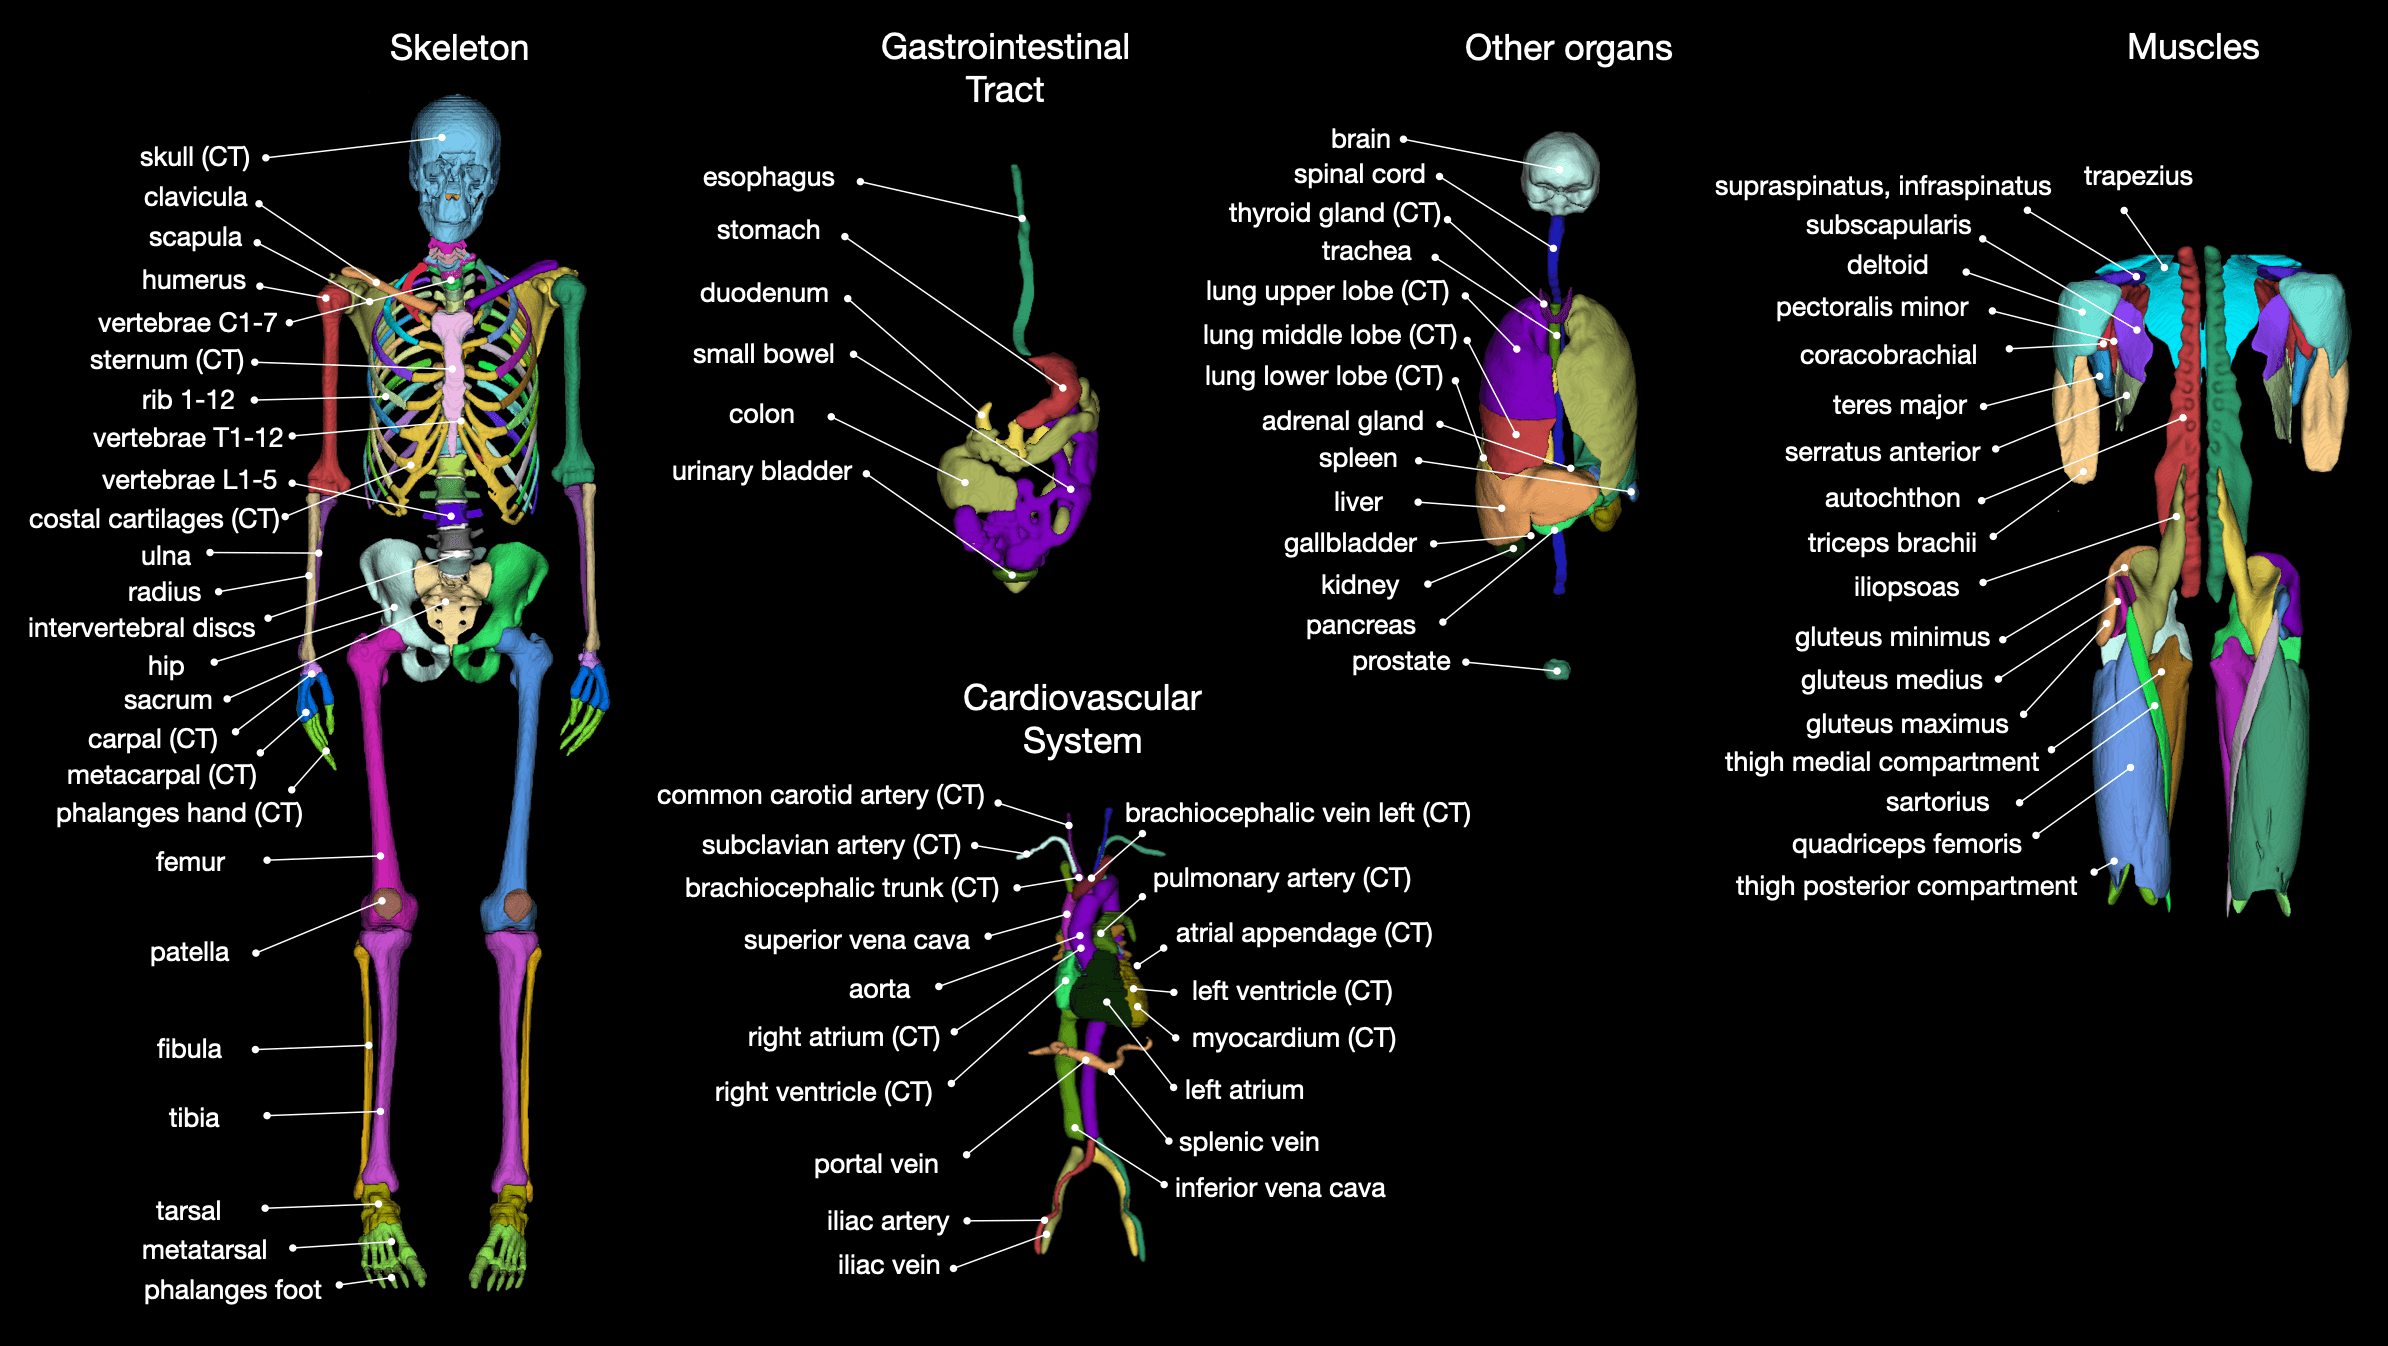

In [ ]:
#with open('/content/license_key_HHL.txt', 'r') as file:
#    license_key = file.read()[:-1]

In [ ]:
### Ejecuta TotalSegmentator
### roi_subset: define las estructuras a segmentar.

if __name__ == "__main__":

    totalsegmentator(path_image, output_path, roi_subset=['lung_upper_lobe_right', 'lung_upper_lobe_left', 'lung_middle_lobe_right',
                                                          'lung_lower_lobe_left', 'lung_lower_lobe_right'])

    ##agregar más estructuras:
    #totalsegmentator(path_image, output_path, task='lung_vessels')
    #totalsegmentator(path_image, output_path, task='lung_nodules')
    #totalsegmentator(path_image, output_path, task='heartchambers_highres', license_number=license_key)
    #totalsegmentator(path_image, output_path, task='coronary_arteries', license_number=license_key)


In [ ]:
## lectura de las máscaras de segmentación
right_lower_lobe = sitk.ReadImage('/content/segmentations/lung_lower_lobe_right.nii.gz')
left_lower_lobe = sitk.ReadImage('/content/segmentations/lung_lower_lobe_left.nii.gz')
right_upper_lobe = sitk.ReadImage('/content/segmentations/lung_upper_lobe_right.nii.gz')
left_upper_lobe = sitk.ReadImage('/content/segmentations/lung_upper_lobe_left.nii.gz')
right_middle_lobe = sitk.ReadImage('/content/segmentations/lung_middle_lobe_right.nii.gz')

### conversión a numpy array
right_lower_lobe_array = sitk.GetArrayFromImage(right_lower_lobe)
left_lower_lobe_array = sitk.GetArrayFromImage(left_lower_lobe)
right_upper_lobe_array = sitk.GetArrayFromImage(right_upper_lobe)
left_upper_lobe_array = sitk.GetArrayFromImage(left_upper_lobe)
right_middle_lobe_array = sitk.GetArrayFromImage(right_middle_lobe)

In [ ]:
## Dimensiones de uno de los array
print(right_lower_lobe_array.shape)

In [ ]:
%matplotlib inline

### Visualización de imagen axial y máscara de segmentación creada
corte_axial = 190

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
# Mostrar imagen 1
axs[0].imshow(volume_array[corte_axial,:,:], cmap='gray')
axs[0].imshow(left_upper_lobe_array[corte_axial,:,:], cmap='inferno', alpha=0.5)
axs[0].set_title('Segmentación de lóbulo superior izquierdo')
axs[0].axis('off')

# Mostrar imagen 2
axs[1].imshow(volume_array[corte_axial,:,:], cmap='gray')
axs[1].imshow(right_upper_lobe_array[corte_axial,:,:], cmap='jet', alpha=0.5)

axs[1].set_title('Segmentación de lóbulo superior derecho')
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
### Matriz de spacing: tamaño del voxel en mm
volume.GetSpacing()

In [ ]:
### Calcular volumen
calcular_volumen(left_lower_lobe_array, volume)

In [ ]:
### Combinar las máscaras
labels = [nombre[:-7] for nombre in os.listdir(output_path)]
print("combinando...", labels)

mascaras_dict = {}

for nombre in labels:
  try:
    path = f"/content/segmentations/{nombre}.nii.gz"
    imagen = sitk.ReadImage(path)
    mascaras_dict[nombre] = imagen
  except:
    continue

arrays_dict = {}

for nombre in mascaras_dict.keys():
  array_name = nombre + '_array'
  array = sitk.GetArrayFromImage(mascaras_dict[nombre])
  arrays_dict[array_name] = array

  combined = np.zeros_like(arrays_dict[list(arrays_dict.keys())[0]], dtype=np.uint8)

for i in range(len(list(arrays_dict.keys())[1:])):
  combined = np.where(arrays_dict[list(arrays_dict.keys())[i+1]], i+2, combined)

combined = np.where(arrays_dict[list(arrays_dict.keys())[0]], 1, combined)

label_img = sitk.GetImageFromArray(combined)
label_img.SetOrigin( mascaras_dict[list(mascaras_dict.keys())[0]].GetOrigin() )
label_img.SetSpacing( mascaras_dict[list(mascaras_dict.keys())[0]].GetSpacing()  )
label_img.SetDirection(mascaras_dict[list(mascaras_dict.keys())[0]].GetDirection())

sitk.WriteImage(label_img, "/content/segmentacion_combinada.nii.gz")

### Cálculo de volumen de las estructuras segmentadas

In [ ]:
for array in arrays_dict.keys():
  mask_array = arrays_dict[array]
  print(f"Volumen de {array[:-6]}: {round(calcular_volumen(mask_array, volume),1)} cc")

### Visualización 3D de máscaras de lóbulos pulmonares

In [ ]:
visualize_3d_mask_labels_sampled(combined, sample_frac=0.1, alpha=0.2, title="Segmentación")

### Visualizador web gratuito:

* https://kitware.github.io/glance/app/

In [ ]:
# Cargar máscara NIfTI
mask_img = nib.load('/content/segmentacion_combinada.nii.gz')

In [ ]:
plotting.view_img(mask_img, bg_img=None, threshold=0, width_view=800, cmap='jet')  # Visor web con scroll 3D
